# Detailed EDA — Receiver General Accounting Transactions

## Objective

Explore the statistical, categorical, temporal, and financial behavior of the Receiver General dataset after the [completed inventory](01_dataset_inventory.ipynb). This notebook develops the inventory findings without replacing or reproducing the entire inventory.

Raw data remains unchanged. All dates, grouping labels, and descriptive candidate flags are temporary analytical variables in separate objects; original columns are never overwritten. Extreme values are investigation candidates, not automatically errors, fraud, or accounting anomalies. Debit/credit codes are accounting directions, not automatically expenses/revenues or cash inflows/outflows.

**Interpretation constraints:** exact fiscal-calendar alignment, relationships between summary and item-level record types, and the complete Kaggle/local-extract provenance chain remain unresolved. The source structure accommodates voucher entries and accounting/control summaries; it is not uniformly one underlying transaction per row. Accounting Effective Date is the chronological variable; Fiscal Month is not converted into a calendar month.

Throughout, “records” means CSV rows. Amount totals are sums of recorded unsigned magnitudes, **not** reconciled revenue, expenditure, cash flow, or unique underlying economic value. Potential overlap among summary and item records is unresolved. Currency/units are not asserted. Concentration describes this extract, not risk. No cleaning, imputation of source values, model fitting, or application implementation is performed.

Documentation already reviewed in the inventory: [official catalogue](https://open.canada.ca/data/en/dataset/fa79f13c-2796-41a9-a9cd-28650ebe0f06), [field dictionary](https://donnees-data.tpsgc-pwgsc.gc.ca/ba1/SGBT-BCMS-dd.xml), and [supporting guide](https://donnees-data.tpsgc-pwgsc.gc.ca/ba1/tcrg-rgat/soutien-support-eng.html). This EDA does not reinterpret the unresolved documentation through inferred mappings.

## 1. Setup and Data Loading

Run from the notebook directory (or project root). Use the project's existing environment. The plotting dependency is checked explicitly. A deep snapshot plus file hashes support the preservation checks at the end. Short column aliases exist only in the separate `eda` DataFrame. Numeric identifiers are categorical grouping variables, never continuous measures.

In [1]:
from pathlib import Path
import hashlib
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

project_root = Path.cwd() if (Path.cwd() / "data/raw").exists() else Path.cwd().parent
raw_path = project_root / "data/raw/Receiver General Accounting Transactions/tcrg-rgat.csv"
inventory_path = project_root / "notebooks/01_dataset_inventory.ipynb"
protected_paths = [inventory_path] + sorted(p for p in (project_root / "data/raw").rglob("*") if p.is_file())
initial_hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in protected_paths}
raw_df = pd.read_csv(raw_path)
raw_snapshot = raw_df.copy(deep=True)
expected_columns = [
    "Accounting-Control-Number-Numéro-contrôle-comptable",
    "Journal-Voucher-Type-Code-Code-du-type-de-pièce-de-journal",
    "Fiscal-Year-Année-Fiscale",
    "Journal-Voucher-Identifier-Identificateur-de-la-pièce-de-journal",
    "Accounting-Effective-Date-Date-d'entrée-en-vigueur-comptable",
    "DepartmentNumber-Numéro-de-Ministère",
    "Fiscal-Month-Mois-Fiscal",
    "Journal-Voucher-Item-Identifier-Identificateur-de-l'item-de-la-pièce-de-journal",
    "Financial-Coding-Block-Bloc-de-codage-financier",
    "Subleger-Account-Identifier-Compte-du-grand-livre-auxiliaire",
    "Credit/Debit-Code-Code-Crédit/Débit",
    "Journal-Voucher-Item-Amount-Montant-de-l'item-de-la-pièce-de-journal",
    "Control-Data-Type-Type-de-données-de-contrôle",
    "Accounting-Summary-Transaction-Line-Count-Sommaire-comptable-transaction-compte-ligne",
    "GBS-Control-Number-Numéro-de-contrôle-du-SBG",
    "General-Ledger-Account-Code-Code-du-compte-du-grand-livre-général",
]
assert raw_df.columns.tolist() == expected_columns
assert raw_df.shape == (9282, 16)
aliases = ["control", "voucher_type", "fiscal_year", "voucher_id", "effective_date_text",
           "department", "fiscal_month", "item", "coding_block", "subledger", "direction",
           "amount", "control_type", "summary_lines", "gbs", "ledger"]
eda = raw_df.rename(columns=dict(zip(expected_columns, aliases))).copy(deep=True)
effective_dates = pd.to_datetime(eda["effective_date_text"], format="%Y-%m-%d", errors="coerce")
eda = eda.assign(effective_date=effective_dates, calendar_month=effective_dates.dt.to_period("M").astype(str))
amount = eda["amount"]
plt.rcParams.update({"figure.figsize": (10, 4), "axes.titlesize": 12, "axes.labelsize": 10})
print("Shape:", raw_df.shape)
print("Environment:", sys.version.split()[0], "pandas", pd.__version__, "matplotlib", matplotlib.__version__)
print("Raw SHA-256:", initial_hashes[str(raw_path)])
print("Exact expected headers confirmed:", len(expected_columns))

Shape: (9282, 16)
Environment: 3.14.7 pandas 3.0.5 matplotlib 3.11.2
Raw SHA-256: c8c5f31461be56af8081d17174a820a0eb1b70514889a8433df2e1b6ab91879d
Exact expected headers confirmed: 16


## 2. EDA Baseline Validation

Reproduce only the core inventory checks. The expected missing counts are taken from the existing inventory, including fields with zero missing values. Parsing failures are counted, never repaired.

In [2]:
expected_missing = pd.Series([0, 26, 0, 9104, 0, 26, 0, 0, 9000, 2186, 0, 0, 178, 26, 239, 9091], index=expected_columns)
pd.testing.assert_series_equal(raw_df.isna().sum(), expected_missing)
baseline = pd.Series({
    "rows": len(raw_df), "columns": raw_df.shape[1],
    "complete_duplicate_occurrences": int(raw_df.duplicated().sum()),
    "missing_cells": int(raw_df.isna().sum().sum()),
    "date_parse_failures": int(effective_dates.isna().sum()),
    "candidate_key_duplicate_occurrences": int(eda.duplicated(["control", "item"]).sum()),
    "candidate_key_rows_with_missing_components": int(eda[["control", "item"]].isna().any(axis=1).sum()),
})
assert baseline.to_dict() == {"rows": 9282, "columns": 16, "complete_duplicate_occurrences": 0,
    "missing_cells": 29876, "date_parse_failures": 0, "candidate_key_duplicate_occurrences": 0,
    "candidate_key_rows_with_missing_components": 0}
assert effective_dates.min() == pd.Timestamp("2023-04-03")
assert effective_dates.max() == pd.Timestamp("2024-01-03")
display(baseline.to_frame("observed"))
print("Baseline matches the inventory. Uniqueness applies to this extract only.")

,observed
rows,9282
columns,16
complete_duplicate_occurrences,0
missing_cells,29876
date_parse_failures,0
candidate_key_duplicate_occurrences,0
candidate_key_rows_with_missing_components,0


Baseline matches the inventory. Uniqueness applies to this extract only.


## 3. Financial Amount Distribution

Quantiles use Pandas' default linear interpolation. Skewness is descriptive sample skewness, not a formal normality test. The first histogram displays only values at or below the 95th percentile; the second includes every positive amount on a log10 display. Zero amounts are reported separately. Neither view removes or changes stored values.

,recorded_amount
count,9.282000e+03
mean,3.298092e+08
std,1.887057e+09
min,0.000000e+00
1%,1.981500e+01
5%,1.135535e+02
25%,5.782925e+02
50%,1.767720e+03
75%,6.725283e+04
90%,1.247278e+08


Sample skewness: 10.103131956677117
Zero / negative / non-finite counts: 2 0 0


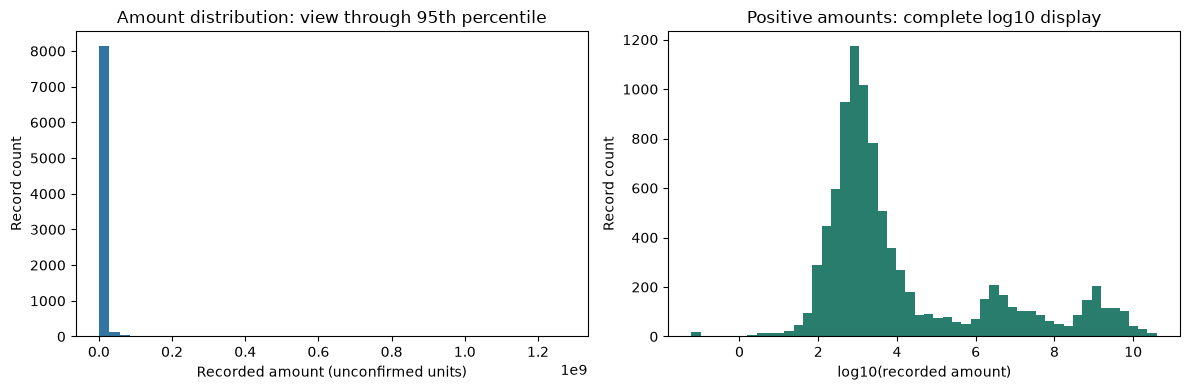

**Observation:** median 1,767.72, mean 329,809,199.76, maximum 39,555,794,411.27, skewness 10.10. The upper tail strongly dominates the mean. The percentile view omits 465 records only from that panel; the log panel omits 2 zeros only from logarithmic display. All records remain available.

In [3]:
amount_stats = amount.describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99, .995, .999])
display(amount_stats.to_frame("recorded_amount"))
print("Sample skewness:", amount.skew())
print("Zero / negative / non-finite counts:", amount.eq(0).sum(), amount.lt(0).sum(), (~np.isfinite(amount)).sum())
q95, q99 = amount.quantile(.95), amount.quantile(.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(amount[amount <= q95], bins=45, color="#3274a1")
axes[0].set(title="Amount distribution: view through 95th percentile", xlabel="Recorded amount (unconfirmed units)", ylabel="Record count")
axes[1].hist(np.log10(amount[amount > 0]), bins=50, color="#287d6c")
axes[1].set(title="Positive amounts: complete log10 display", xlabel="log10(recorded amount)", ylabel="Record count")
fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** median {amount.median():,.2f}, mean {amount.mean():,.2f}, maximum {amount.max():,.2f}, skewness {amount.skew():.2f}. The upper tail strongly dominates the mean. The percentile view omits {(amount > q95).sum():,} records only from that panel; the log panel omits {amount.eq(0).sum()} zeros only from logarithmic display. All records remain available."))

## 4. Debit / Credit Analysis

All grouped sums retain recorded signs (here amounts are nonnegative); no DR/CR sign transformation or netting is applied. Missing category labels are retained in grouped tables through `dropna=False`. The shared summary includes quartiles and skewness.

,records,total,mean,median,std,minimum,maximum,skewness,q25,q75
direction,,,,,,,,,,
CR,2051,5.188250e+10,2.529620e+07,1723.06,3.318139e+08,0.0,6.184370e+09,15.915322,696.340,6710.690
DR,7231,3.009406e+12,4.161812e+08,1785.92,2.122776e+09,0.0,3.955579e+10,8.975761,546.275,1737419.625


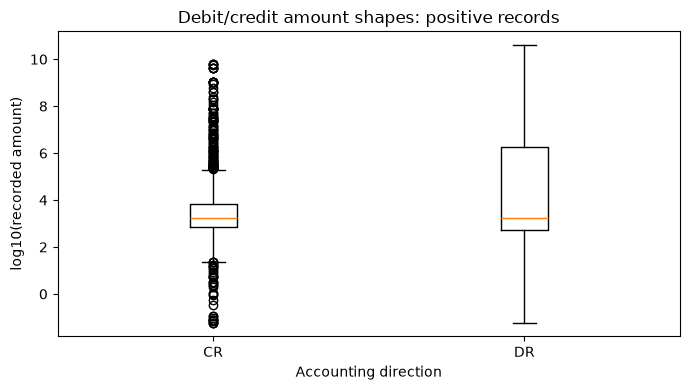

**Observation:** DR has 7,231 records and 98.31% of recorded magnitude, but DR/CR medians are 1,785.92 / 1,723.06. Similar centers coexist with very different upper tails. **Implication:** direction is useful for stratification, but not sufficient by itself. These are descriptively different observed distributions; independence and formal population differences have not been established. DR is not labeled expense and CR is not labeled revenue.

In [4]:
def summarize_amount(by):
    grouped = eda.groupby(by, dropna=False, observed=True)["amount"]
    result = grouped.agg(records="size", total="sum", mean="mean", median="median", std="std", minimum="min", maximum="max", skewness="skew")
    result["q25"] = grouped.quantile(.25)
    result["q75"] = grouped.quantile(.75)
    return result

direction_stats = summarize_amount("direction")
display(direction_stats)
fig, ax = plt.subplots(figsize=(7, 4))
labels = direction_stats.index.tolist()
ax.boxplot([np.log10(eda.loc[(eda.direction == label) & (amount > 0), "amount"]) for label in labels], tick_labels=labels, showfliers=True)
ax.set(title="Debit/credit amount shapes: positive records", xlabel="Accounting direction", ylabel="log10(recorded amount)")
fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** DR has {direction_stats.loc['DR', 'records']:,.0f} records and {direction_stats.loc['DR', 'total']/amount.sum()*100:.2f}% of recorded magnitude, but DR/CR medians are {direction_stats.loc['DR', 'median']:,.2f} / {direction_stats.loc['CR', 'median']:,.2f}. Similar centers coexist with very different upper tails. **Implication:** direction is useful for stratification, but not sufficient by itself. These are descriptively different observed distributions; independence and formal population differences have not been established. DR is not labeled expense and CR is not labeled revenue."))

## 5. Journal Voucher Type Analysis

Codes remain labels without inferred business meanings. “Rare” below means at most 10 records in this extract, an exploratory reporting threshold only. All categories, including missing labels, appear in the table; plotted categories are selected by stated rankings.

,records,total,mean,median,std,minimum,maximum,skewness,q25,q75
voucher_type,,,,,,,,,,
ADEPT,3439,7.220814e+06,2.099684e+03,6.200000e+02,2.228191e+04,2.450000e+00,8.568388e+05,32.329201,2.617500e+02,1.391100e+03
JVEFI,2289,4.541388e+07,1.984005e+04,2.134070e+03,2.029696e+05,2.276000e+01,7.214387e+06,27.316231,9.456400e+02,6.549800e+03
JVFIR,563,8.793624e+09,1.561923e+07,3.904917e+06,4.803779e+07,2.082612e+04,7.049388e+08,9.719184,1.863279e+06,1.193638e+07
DOMFR,386,5.885933e+05,1.524853e+03,6.535250e+02,3.810012e+03,5.501000e+01,5.021808e+04,8.704167,2.695000e+02,1.477977e+03
JVIVI,188,1.636920e+06,8.707023e+03,7.373240e+03,6.520136e+03,4.025000e+01,2.841084e+04,0.922789,3.634358e+03,1.195231e+04
EPAYR,187,7.449935e+08,3.983923e+06,2.901739e+06,3.289890e+06,7.575422e+05,2.158256e+07,3.070447,2.129148e+06,4.723379e+06
JVBDP,187,1.297876e+12,6.940513e+09,4.710401e+09,6.776580e+09,1.780480e+08,3.259303e+10,2.098182,2.760387e+09,7.613726e+09
JVLVP,187,3.591677e+11,1.920683e+09,1.171680e+09,1.872406e+09,5.010000e+00,9.048852e+09,1.375725,5.021644e+08,2.735958e+09
RDBOA,187,8.753229e+09,4.680871e+07,2.264687e+07,8.786191e+07,4.134175e+06,8.330815e+08,6.170783,1.137156e+07,4.783656e+07


Observed non-null voucher types: 39 Missing labels: 26
Rare groups (including missing if eligible): 15


,records,median,maximum
voucher_type,,,
BNKFE,6,1.160000e+00,1.991000e+01
CITYE,2,5.820093e+08,5.820093e+08
CRCPC,4,4.366835e+03,9.785350e+03
FMSPM,9,3.689513e+08,4.164338e+08
FORFR,3,4.145400e+02,6.616600e+02
GCRCD,4,6.546126e+04,1.302293e+05
JVBRC,10,6.541464e+08,6.551358e+09
LVTSR,5,5.010000e+00,7.832151e+07
MDDEP,9,2.693210e+05,2.157631e+06


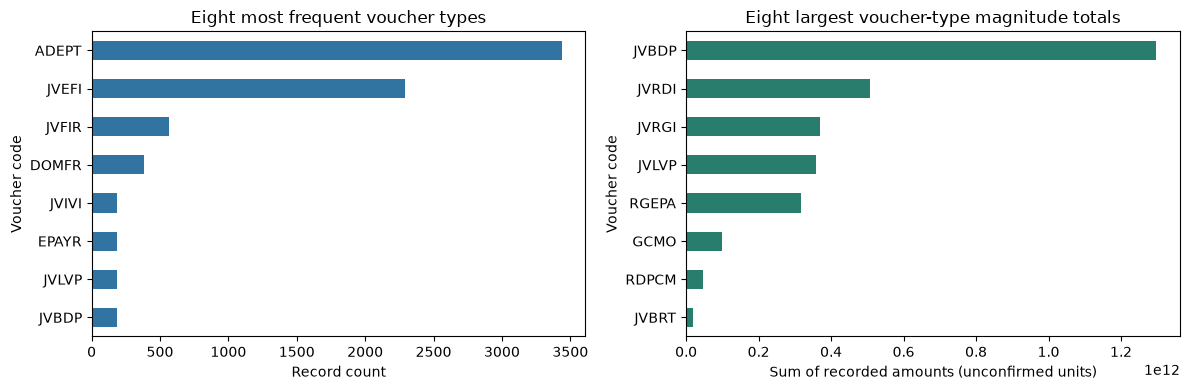

**Observation:** ADEPT leads counts (3,439) with median 620.00; JVBDP leads recorded magnitude with only 187 rows and median 4,710,400,895.40. Voucher type separates amount scales much more strongly than the overall DR/CR medians. Rare codes do not become errors merely because they are rare.

In [5]:
type_stats = summarize_amount("voucher_type")
display(type_stats.sort_values("records", ascending=False))
rare_types = type_stats.loc[type_stats.records <= 10]
print("Observed non-null voucher types:", eda.voucher_type.nunique(), "Missing labels:", eda.voucher_type.isna().sum())
print("Rare groups (including missing if eligible):", len(rare_types))
display(rare_types[["records", "median", "maximum"]])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
type_stats.nlargest(8, "records")["records"].sort_values().plot.barh(ax=axes[0], color="#3274a1")
axes[0].set(title="Eight most frequent voucher types", xlabel="Record count", ylabel="Voucher code")
type_stats.nlargest(8, "total")["total"].sort_values().plot.barh(ax=axes[1], color="#287d6c")
axes[1].set(title="Eight largest voucher-type magnitude totals", xlabel="Sum of recorded amounts (unconfirmed units)", ylabel="Voucher code")
fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** ADEPT leads counts ({type_stats.loc['ADEPT','records']:,.0f}) with median {type_stats.loc['ADEPT','median']:,.2f}; JVBDP leads recorded magnitude with only {type_stats.loc['JVBDP','records']:,.0f} rows and median {type_stats.loc['JVBDP','median']:,.2f}. Voucher type separates amount scales much more strongly than the overall DR/CR medians. Rare codes do not become errors merely because they are rare."))

## 6. Department Analysis

Department numbers are identifiers, not measurements. No department identity is inferred. Counts refer to records, not independently verified business transactions. Missing department labels remain a separate group.

In [6]:
department_stats = summarize_amount("department")
display(department_stats.sort_values("records", ascending=False))
known_department = department_stats.loc[department_stats.index.notna()]
print("Known departments:", len(known_department))
print("Missing department records:", eda.department.isna().sum())
top5_department_record_share = known_department.records.nlargest(5).sum()/len(eda)*100
top2_department_amount_share = known_department.total.nlargest(2).sum()/amount.sum()*100
print("Top 5 known departments, share of all records:", top5_department_record_share)
print("Top 2 known departments, share of all recorded magnitude:", top2_department_amount_share)
display(Markdown(f"**Observation:** the five busiest known departments contain {top5_department_record_share:.2f}% of rows; departments 97 and 6 together account for {top2_department_amount_share:.2f}% of recorded magnitude. Department 122 leads record count, while 97 leads magnitude. Activity and amount concentration measure different things. Mixed voucher types and summary granularity may explain part of the difference; no risk conclusion follows."))

,records,total,mean,median,std,minimum,maximum,skewness,q25,q75
department,,,,,,,,,,
122.0,2390,5.056860e+06,2.115841e+03,4.171250e+02,2.495459e+04,2.45,8.568388e+05,30.570225,1.877500e+02,9.837900e+02
97.0,2101,2.416253e+12,1.150049e+09,1.361413e+07,3.068168e+09,0.55,3.259303e+10,5.441069,1.699884e+06,9.453340e+08
14.0,1436,2.205950e+06,1.536177e+03,9.695000e+02,2.380174e+03,3.43,4.057152e+04,8.881579,5.548150e+02,1.765363e+03
18.0,1318,3.664393e+07,2.780267e+04,2.589070e+03,2.633452e+05,22.76,7.214387e+06,21.548524,1.029030e+03,8.752315e+03
6.0,860,6.420299e+11,7.465464e+08,8.643925e+04,3.583616e+09,0.00,3.955579e+10,6.004448,1.187640e+03,7.426623e+06
5.0,456,3.846812e+06,8.435992e+03,2.213130e+03,3.177473e+04,70.76,3.857091e+05,8.981116,1.055923e+03,5.770368e+03
30.0,82,7.551699e+05,9.209389e+03,2.084140e+03,3.480794e+04,117.07,3.065404e+05,7.949435,7.576200e+02,4.765517e+03
163.0,51,1.372144e+06,2.690478e+04,3.820180e+03,1.053399e+05,503.63,7.540622e+05,6.841353,1.372790e+03,1.733983e+04
127.0,50,5.793115e+06,1.158623e+05,2.317230e+03,3.732049e+05,0.00,2.157631e+06,4.588696,1.071455e+03,4.398460e+04


Known departments: 54
Missing department records: 26
Top 5 known departments, share of all records: 87.31954320189614
Top 2 known departments, share of all recorded magnitude: 99.90179639928476


**Observation:** the five busiest known departments contain 87.32% of rows; departments 97 and 6 together account for 99.90% of recorded magnitude. Department 122 leads record count, while 97 leads magnitude. Activity and amount concentration measure different things. Mixed voucher types and summary granularity may explain part of the difference; no risk conclusion follows.

## 7. Accounting Dimensions

Coverage is reported before any account analysis. Tables describe only the nonmissing subset for each dimension, with its size shown. Absence is not imputed. Source documentation permits some record-type-dependent blanks, but this does not establish the reason for every missing local value.

In [7]:
account_fields = ["ledger", "subledger", "coding_block", "control_type"]
coverage = pd.DataFrame({"populated_records": eda[account_fields].notna().sum(), "coverage_percent": eda[account_fields].notna().mean()*100, "known_categories": eda[account_fields].nunique()})
display(coverage)
for field in account_fields:
    table = summarize_amount(field)
    known = table.loc[table.index.notna()]
    print(field, "— top 8 known categories by record count; full known-category count:", len(known))
    display(known.nlargest(8, "records")[["records", "total", "median", "maximum"]])
print("Summary-line count description (known values only):")
display(eda.summary_lines.describe().to_frame("summary_lines"))
print("Known counts >1 / zero / missing:", eda.summary_lines.gt(1).sum(), eda.summary_lines.eq(0).sum(), eda.summary_lines.isna().sum())

,populated_records,coverage_percent,known_categories
ledger,191,2.057746,11
subledger,7096,76.449041,354
coding_block,282,3.038138,18
control_type,9104,98.082310,34


ledger — top 8 known categories by record count; full known-category count: 11


,records,total,median,maximum
ledger,,,,
12080,67,4.639625e+10,5.483002e+06,6.184370e+09
6B000,66,4.209883e+10,4.960405e+06,6.184370e+09
15000,25,6.646054e+09,3.000000e+07,4.168221e+09
61000,19,1.586534e+09,3.000000e+07,4.125333e+08
25401,4,1.494463e+09,3.751703e+08,4.164338e+08
25301,3,1.119292e+09,3.689513e+08,3.837179e+08
10011,2,4.988040e+07,2.494020e+07,4.988038e+07
62000,2,1.993557e+07,9.967783e+06,9.967783e+06


subledger — top 8 known categories by record count; full known-category count: 354


,records,total,median,maximum
subledger,,,,
60000.0,788,5.934469e+11,53926.685,3.955579e+10
50054.0,334,1.388068e+06,2197.690,3.140462e+04
186369.0,180,8.231082e+06,4334.835,4.733163e+06
182184.0,157,1.939507e+06,5198.850,3.196211e+05
1221494.0,150,1.096380e+05,451.000,3.127920e+03
1221887.0,130,2.092912e+05,1098.635,6.486000e+03
1224394.0,121,6.257113e+04,347.700,1.993600e+03
1222509.0,120,4.266223e+05,2172.640,1.401529e+04


...

control_type — top 8 known categories by record count; full known-category count: 34


,records,total,median,maximum
control_type,,,,
COK,3825,7.809407e+06,6.247400e+02,8.568388e+05
CMC,2289,4.541388e+07,2.134070e+03,7.214387e+06
JMT,563,8.793624e+09,3.904917e+06,7.049388e+08
JMZ,208,3.613901e+11,8.821508e+08,1.248296e+10
CMD,188,1.636920e+06,7.373240e+03,2.841084e+04
CMI,187,5.066731e+11,1.898929e+05,3.955579e+10
JMG,187,3.699359e+11,1.170940e+09,1.271950e+10
JML,187,3.591677e+11,1.171680e+09,9.048852e+09


Summary-line count description (known values only):


,summary_lines
count,9256.000000
mean,5.036301
std,13.199978
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,98.000000


Known counts >1 / zero / missing: 3490 0 26


**Interpretation:** Control Data Type has broad coverage and may help distinguish accounting processes. Subledger offers a larger set of potential account peers but its missingness must be examined by record type and amount, not just row percentage. General Ledger Account and Financial Coding Block describe small selected subsets; their apparent distributions cannot represent the entire extract. Summary-line counts provide context about grouped detail, but dividing amounts by counts would not establish comparable individual transactions. No such reconstruction is performed.

## 8. Temporal Analysis

Calendar periods derive exclusively from Accounting Effective Date. Daily tables contain observed dates only; dates with no rows are reported as absent from the extract, not imputed as zero financial activity. January 2024 is an endpoint fragment, not a full comparable month. Fiscal labels are untouched and their exact alignment remains unresolved.

,records,total,median,q25,q75,maximum
calendar_month,,,,,,
2023-04,1010,3.635885e+11,2817.320,762.3600,4.716940e+05,2.645298e+10
2023-05,1063,3.639932e+11,1740.730,570.3550,2.987586e+04,2.965005e+10
2023-06,1021,3.315026e+11,2103.660,626.0000,7.550820e+04,2.388370e+10
2023-07,778,3.003968e+11,2369.860,697.9300,1.592366e+06,3.121248e+10
2023-08,1126,4.016951e+11,1510.050,525.0025,9.534755e+04,3.259303e+10
2023-09,1002,3.646799e+11,1666.495,510.3525,9.008526e+04,3.955579e+10
2023-10,1134,2.893216e+11,1309.795,521.1700,1.368306e+04,2.245334e+10
2023-11,1076,3.022912e+11,1512.375,505.7775,2.818326e+04,2.360011e+10
2023-12,1010,3.301643e+11,1850.775,583.1600,6.053044e+04,2.300006e+10


Observed dates: 188 Calendar days in observed interval: 276 Dates with no rows: 88
Days represented by month:


,min,max,nunique
calendar_month,,,
2023-04,2023-04-03,2023-04-28,19
2023-05,2023-05-01,2023-05-31,22
2023-06,2023-06-01,2023-06-30,22
2023-07,2023-07-04,2023-07-31,20
2023-08,2023-08-01,2023-08-31,23
2023-09,2023-09-01,2023-09-29,20
2023-10,2023-10-03,2023-10-31,20
2023-11,2023-11-01,2023-11-30,21
2023-12,2023-12-01,2023-12-29,19


Five largest daily magnitude totals:


,records,total,median,maximum
effective_date,,,,
2023-08-03,49,5.997774e+10,1269.17,3.259303e+10
2023-09-01,62,5.807072e+10,1485.49,3.955579e+10
2023-08-31,65,5.737262e+10,1059.40,3.238400e+10
2023-06-08,51,5.576184e+10,1700.00,2.388370e+10
2023-09-14,25,5.470634e+10,7647.22,2.698105e+10


Five busiest dates:


,records,total,median
effective_date,,,
2023-04-13,96,4.319747e+10,1937.575
2023-09-13,92,6.188586e+09,1769.340
2023-04-14,90,7.237397e+09,6336.930
2023-04-04,86,3.582718e+10,2598.915
2023-04-03,84,2.318930e+10,1265.190


Five quietest observed dates:


,records,total,median
effective_date,,,
2024-01-03,16,1.749290e+07,3233.365
2023-06-26,17,8.773375e+09,2203975.920
2023-08-07,20,1.122017e+09,64830.990
2023-07-10,21,7.143726e+09,172966.140
2023-06-20,22,1.760530e+10,5748.515


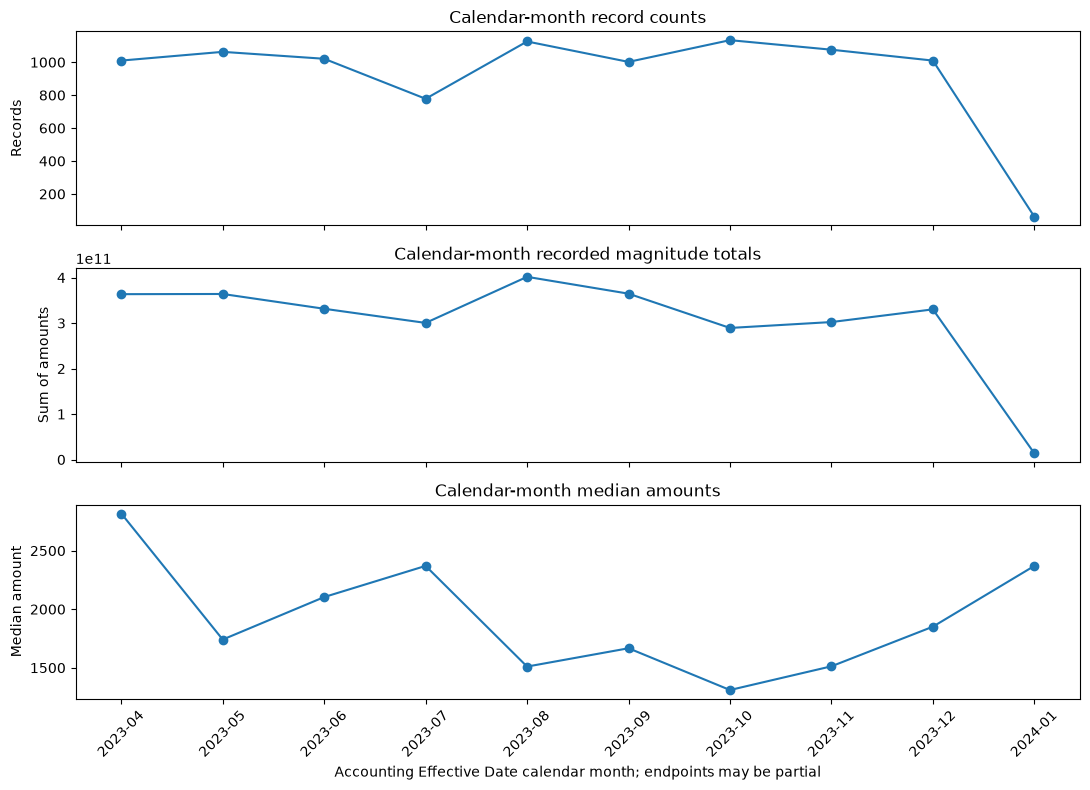

**Observation:** 2023-10 has the most rows (1,134); 2023-08 has the largest monthly recorded total. January 2024 has only 62 records through January 3. The highest daily total occurs on 2023-08-03. Quiet dates, gaps, and spikes are descriptive; completeness, holidays, reporting schedules, and economic causes are unverified. No annual seasonality is established by less than one year of effective dates.

In [8]:
daily = summarize_amount("effective_date").sort_index()
monthly = summarize_amount("calendar_month").sort_index()
display(monthly[["records", "total", "median", "q25", "q75", "maximum"]])
calendar_days = pd.date_range(effective_dates.min(), effective_dates.max(), freq="D")
absent_dates = calendar_days.difference(pd.DatetimeIndex(daily.index))
print("Observed dates:", len(daily), "Calendar days in observed interval:", len(calendar_days), "Dates with no rows:", len(absent_dates))
print("Days represented by month:")
display(eda.groupby("calendar_month").effective_date.agg(["min", "max", "nunique"]))
print("Five largest daily magnitude totals:"); display(daily.nlargest(5,"total")[["records","total","median","maximum"]])
print("Five busiest dates:"); display(daily.nlargest(5,"records")[["records","total","median"]])
print("Five quietest observed dates:"); display(daily.nsmallest(5,"records")[["records","total","median"]])
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, field, title, ylabel in zip(axes, ["records", "total", "median"], ["Calendar-month record counts", "Calendar-month recorded magnitude totals", "Calendar-month median amounts"], ["Records", "Sum of amounts", "Median amount"]):
    ax.plot(monthly.index, monthly[field], marker="o")
    ax.set(title=title, ylabel=ylabel)
axes[-1].set_xlabel("Accounting Effective Date calendar month; endpoints may be partial")
axes[-1].tick_params(axis="x", rotation=45)
fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** {monthly.records.idxmax()} has the most rows ({monthly.records.max():,.0f}); {monthly.total.idxmax()} has the largest monthly recorded total. January 2024 has only {monthly.loc['2024-01','records']:,.0f} records through January 3. The highest daily total occurs on {daily.total.idxmax():%Y-%m-%d}. Quiet dates, gaps, and spikes are descriptive; completeness, holidays, reporting schedules, and economic causes are unverified. No annual seasonality is established by less than one year of effective dates."))

## 9. Temporal × Financial Relationships

Use a fixed extract-wide 99th percentile to describe high-value activity consistently across months. This is a descriptive cutoff, not a learned anomaly threshold. Report counts and rates because monthly record counts differ. Type and department mix help contextualize changes in period totals.

,records,above_p99_records,above_p99_fraction
calendar_month,,,
2023-04,1010,9,0.008911
2023-05,1063,12,0.011289
2023-06,1021,12,0.011753
2023-07,778,7,0.008997
2023-08,1126,12,0.010657
2023-09,1002,11,0.010978
2023-10,1134,8,0.007055
2023-11,1076,10,0.009294
2023-12,1010,12,0.011881


size           sum    median
calendar_month direction                              
2023-04        CR          362  1.401257e+10  2126.140
               DR          648  3.495760e+11  3731.345
2023-05        CR          224  7.618205e+08  1322.700
               DR          839  3.632313e+11  2000.000
2023-06        CR          341  6.211243e+06  2195.000
               DR          680  3.314964e+11  1996.115
2023-07        CR          170  2.867909e+07  1405.960
               DR          608  3.003682e+11  3588.000
2023-08        CR          109  1.573170e+10   743.740
               DR         1017  3.859634e+11  1625.000
2023-09        CR          244  1.077072e+10  1701.435
               DR          758  3.539091e+11  1566.460
2023-10        CR          108  2.112404e+07  1076.545
               DR         1026  2.893004e+11  1339.140
2023-11        CR          180  7.172322e+07  1254.580
               DR          896  3.022194e+11  1590.565
2023-12        CR          299  1.047738e+10  3230.260
               DR          711  3.196869e+11  1387.150
2024-01        CR           14  5.749175e+05  2614.745
               DR           48  1.365536e+10  2160.920

Calendar-month counts for five most frequent types:


voucher_type,ADEPT,JVEFI,JVFIR,DOMFR,JVIVI
calendar_month,,,,,
2023-04,238,362,56,33,19
2023-05,401,235,66,65,22
2023-06,346,267,66,47,22
2023-07,198,222,60,23,20
2023-08,488,221,69,36,23
2023-09,420,184,60,57,20
2023-10,485,274,60,55,20
2023-11,432,247,63,50,21
2023-12,408,262,57,20,19


Calendar-month counts for five busiest known departments:


department,122.0,97.0,14.0,18.0,6.0
calendar_month,,,,,
2023-04,174,217,99,181,108
2023-05,282,255,180,132,86
2023-06,224,248,176,162,80
2023-07,118,223,104,136,91
2023-08,328,247,199,132,117
2023-09,316,219,154,114,111
2023-10,336,220,194,165,87
2023-11,319,242,171,140,88
2023-12,278,213,151,147,86


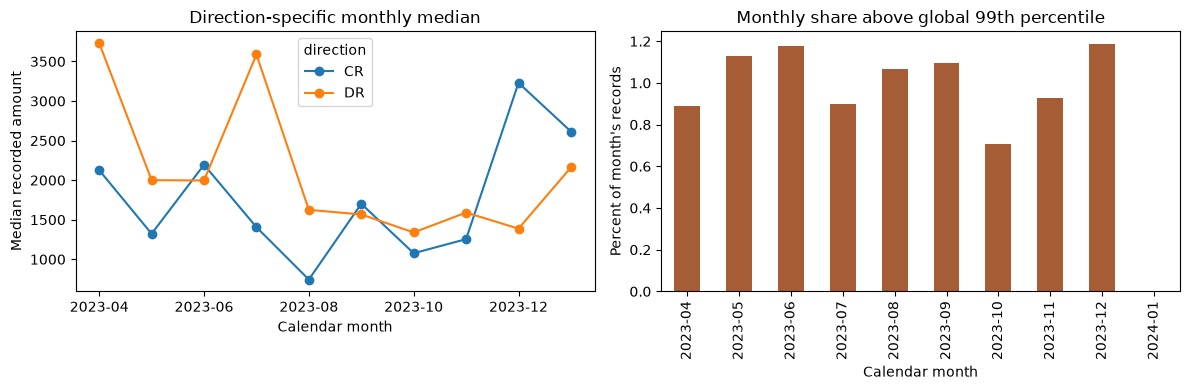

**Observation:** the fixed cutoff is 7,346,044,042.76. Above-cutoff counts range from 0 to 12 per observed month. Changes in direction/type/department composition can affect aggregate behavior. **Hypothesis:** some temporal variation is compositional; the tables do not establish causation or an adjusted trend.

In [9]:
eda_high = eda.assign(above_global_p99=amount > q99)
high_by_month = eda_high.groupby("calendar_month").above_global_p99.agg(["size", "sum", "mean"])
high_by_month.columns = ["records", "above_p99_records", "above_p99_fraction"]
display(high_by_month)
month_direction = eda.groupby(["calendar_month","direction"]).amount.agg(["size","sum","median"])
display(month_direction)
top_types = type_stats.nlargest(5,"records").index
print("Calendar-month counts for five most frequent types:")
display(pd.crosstab(eda.calendar_month, eda.voucher_type).reindex(columns=top_types))
print("Calendar-month counts for five busiest known departments:")
display(pd.crosstab(eda.calendar_month, eda.department).reindex(columns=known_department.nlargest(5,"records").index))
fig, axes = plt.subplots(1,2,figsize=(12,4))
month_direction["median"].unstack().plot(ax=axes[0],marker="o")
axes[0].set(title="Direction-specific monthly median", xlabel="Calendar month", ylabel="Median recorded amount")
high_by_month["above_p99_fraction"].mul(100).plot.bar(ax=axes[1],color="#a65c35")
axes[1].set(title="Monthly share above global 99th percentile", xlabel="Calendar month", ylabel="Percent of month's records")
fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** the fixed cutoff is {q99:,.2f}. Above-cutoff counts range from {high_by_month.above_p99_records.min()} to {high_by_month.above_p99_records.max()} per observed month. Changes in direction/type/department composition can affect aggregate behavior. **Hypothesis:** some temporal variation is compositional; the tables do not establish causation or an adjusted trend."))

## 10. Concentration Analysis

Rank known categories separately from missing labels. Shares of all records/amounts use the whole extract as denominator; within-known shares use only populated labels. Missing accounts are never treated as a single real account. Cumulative shares are sums of recorded magnitudes and may include unresolved overlapping summaries.

department — top five known groups ranked by recorded amount


,records,total,percent_all_amount,cumulative_percent_all_amount,cumulative_percent_known_amount
department,,,,,
97.0,2101,2.416253e+12,78.929263,78.929263,79.005307
6.0,860,6.420299e+11,20.972534,99.901796,99.998047
18.0,1318,3.664393e+07,0.001197,99.902993,99.999245
127.0,50,5.793115e+06,0.000189,99.903183,99.999434
122.0,2390,5.056860e+06,0.000165,99.903348,99.999600


voucher_type — top five known groups ranked by recorded amount


,records,total,percent_all_amount,cumulative_percent_all_amount,cumulative_percent_known_amount
voucher_type,,,,,
JVBDP,187,1.297876e+12,42.396384,42.396384,42.437231
JVRDI,187,5.066731e+11,16.550974,58.947358,59.004151
JVRGI,187,3.699359e+11,12.084319,71.031677,71.100112
JVLVP,187,3.591677e+11,11.732566,82.764242,82.843982
RGEPA,186,3.156896e+11,10.312310,93.076553,93.166227


subledger — top five known groups ranked by recorded amount


...

control_type — top five known groups ranked by recorded amount


,records,total,percent_all_amount,cumulative_percent_all_amount,cumulative_percent_known_amount
control_type,,,,,
JMY,187,1.297876e+12,42.396384,42.396384,43.857915
CMI,187,5.066731e+11,16.550974,58.947358,60.979450
JMG,187,3.699359e+11,12.084319,71.031677,73.480352
JMZ,208,3.613901e+11,11.805161,82.836837,85.692472
JML,187,3.591677e+11,11.732566,94.569403,97.829494


control — top five known groups ranked by recorded amount


,records,total,percent_all_amount,cumulative_percent_all_amount,cumulative_percent_known_amount
control,,,,,
202324800003,1,3.955579e+10,1.292129,1.292129,1.292129
202321600001,1,3.259303e+10,1.064683,2.356812,2.356812
202324400001,1,3.238400e+10,1.057855,3.414667,3.414667
202318800003,1,3.121248e+10,1.019586,4.434253,4.434253
202312200008,1,2.965005e+10,0.968548,5.402801,5.402801


,known_groups,missing_records_percent,missing_amount_percent,top1_known_amount_percent_all,top5_known_amount_percent_all,top5_known_records_percent_all
dimension,,,,,,
department,54,0.280112,0.096252,78.929263,99.903348,87.319543
voucher_type,39,0.280112,0.096252,42.396384,93.076553,73.960353
subledger,354,23.550959,80.564404,19.385523,19.431068,17.334626
control_type,34,1.917690,3.332422,42.396384,94.569403,76.201250
control,9134,0.000000,0.000000,1.292129,5.402801,0.883430


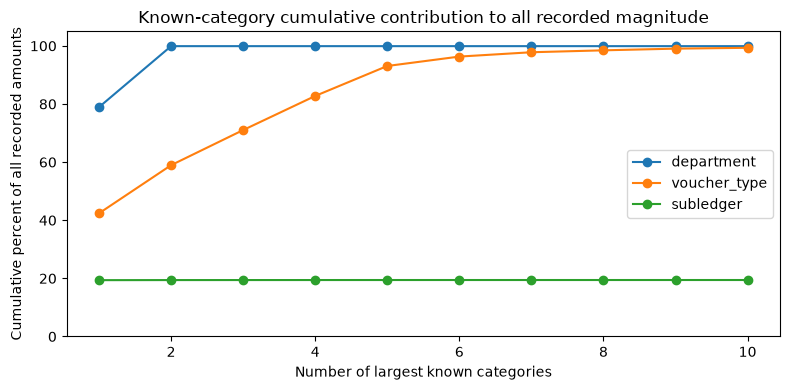

**Observation:** the five largest known voucher types contribute 93.08% of magnitude. Missing subledger labels account for 23.55% of records but 80.56% of magnitude. Apparent account concentration is therefore highly coverage-dependent. Accounting-control grouping is descriptive only; it does not deduplicate underlying activity.

In [10]:
concentration_rows = []
concentration_tables = {}
for field in ["department","voucher_type","subledger","control_type","control"]:
    table = summarize_amount(field)
    known = table.loc[table.index.notna()].sort_values("total",ascending=False).copy()
    known["percent_all_amount"] = known.total / amount.sum()*100
    known["cumulative_percent_all_amount"] = known.percent_all_amount.cumsum()
    known["cumulative_percent_known_amount"] = known.total.cumsum()/known.total.sum()*100
    concentration_tables[field] = known
    missing = eda[field].isna()
    concentration_rows.append({"dimension":field,"known_groups":len(known),
        "missing_records_percent":missing.mean()*100,"missing_amount_percent":amount[missing].sum()/amount.sum()*100,
        "top1_known_amount_percent_all":known.total.nlargest(1).sum()/amount.sum()*100,
        "top5_known_amount_percent_all":known.total.nlargest(5).sum()/amount.sum()*100,
        "top5_known_records_percent_all":known.records.nlargest(5).sum()/len(eda)*100})
    print(field, "— top five known groups ranked by recorded amount")
    display(known[["records","total","percent_all_amount","cumulative_percent_all_amount","cumulative_percent_known_amount"]].head(5))
concentration = pd.DataFrame(concentration_rows).set_index("dimension")
display(concentration)
fig, ax = plt.subplots(figsize=(8,4))
for field in ["department","voucher_type","subledger"]:
    values = concentration_tables[field].cumulative_percent_all_amount
    ax.plot(range(1,min(10,len(values))+1),values.iloc[:10],marker="o",label=field)
ax.set(title="Known-category cumulative contribution to all recorded magnitude", xlabel="Number of largest known categories", ylabel="Cumulative percent of all recorded amounts", ylim=(0,105))
ax.legend(); fig.tight_layout(); plt.show(); plt.close(fig)
display(Markdown(f"**Observation:** the five largest known voucher types contribute {concentration.loc['voucher_type','top5_known_amount_percent_all']:.2f}% of magnitude. Missing subledger labels account for {concentration.loc['subledger','missing_records_percent']:.2f}% of records but {concentration.loc['subledger','missing_amount_percent']:.2f}% of magnitude. Apparent account concentration is therefore highly coverage-dependent. Accounting-control grouping is descriptive only; it does not deduplicate underlying activity."))

## 11. Missingness Patterns

Missingness is measured on original values and summarized by voucher type, direction, department, calendar month, and control type. Tables show group size alongside missing percentages. Associations are observed patterns; neither random missingness nor a definitive structural cause is established by these summaries.

voucher_type — missing percentages; department/control-type display limited to 12 largest groups


,records,voucher_id,ledger,coding_block,subledger,control_type,summary_lines,department,gbs
voucher_type,,,,,,,,,
ADEPT,3439,100.0,100.000000,100.0,0.000000,0.0,0.0,0.0,0.668799
AFDEP,61,100.0,100.000000,100.0,0.000000,0.0,0.0,0.0,0.000000
BNKFE,6,100.0,100.000000,100.0,0.000000,0.0,0.0,0.0,0.000000
CADJU,11,100.0,90.909091,0.0,0.000000,0.0,0.0,0.0,0.000000
CGAGR,16,100.0,100.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
CITYE,2,100.0,100.000000,0.0,100.000000,0.0,0.0,0.0,0.000000
CRCPC,4,100.0,75.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
DOMFR,386,100.0,100.000000,100.0,0.000000,0.0,0.0,0.0,0.000000
EPAYR,187,100.0,100.000000,100.0,100.000000,0.0,0.0,0.0,0.534759


direction — missing percentages; department/control-type display limited to 12 largest groups


,records,voucher_id,ledger,coding_block,subledger,control_type,summary_lines,department,gbs
direction,,,,,,,,,
CR,2051,95.660653,95.563140,93.759142,2.584105,4.339347,0.633837,0.633837,4.973184
DR,7231,98.769188,98.617065,97.870281,29.497995,1.230812,0.179781,0.179781,1.894620


department — missing percentages; department/control-type display limited to 12 largest groups


...

,records,voucher_id,ledger,coding_block,subledger,control_type,summary_lines,department,gbs
control_type,,,,,,,,,
COK,3825,100.0,100.000000,100.000000,0.0,0.0,0.0,0.0,0.601307
CMC,2289,100.0,100.000000,100.000000,0.0,0.0,0.0,0.0,0.655308
JMT,563,100.0,100.000000,100.000000,100.0,0.0,0.0,0.0,1.065719
JMZ,208,100.0,99.038462,89.423077,100.0,0.0,0.0,0.0,0.480769
CMD,188,100.0,100.000000,100.000000,0.0,0.0,0.0,0.0,1.063830
JMY,187,100.0,100.000000,100.000000,100.0,0.0,0.0,0.0,0.534759
JND,187,100.0,100.000000,100.000000,100.0,0.0,0.0,0.0,0.534759
JML,187,100.0,100.000000,100.000000,100.0,0.0,0.0,0.0,0.534759
JMR,187,100.0,100.000000,100.000000,100.0,0.0,0.0,0.0,0.534759


Most common joint missingness patterns (True = missing):


records
voucher_id ledger coding_block subledger control_type summary_lines department gbs           
True       True   True         False     False        False         False      False     6922
                               True      False        False         False      False     2018
False      False  False        True      True         False         False      True        78
                               False     True         False         False      True        70
True       True   False        True      False        False         False      False       47
                  True         False     False        False         False      True        45
                  False        False     False        False         False      False       39
                  True         True      False        False         False      True        15
False      False  False        False     True         True          True       True        13
                               True      True         True          True       True        13

Voucher-reference presence versus control-type presence:


control_type_present,False,True
voucher_id_present,,
False,0,9104
True,178,0


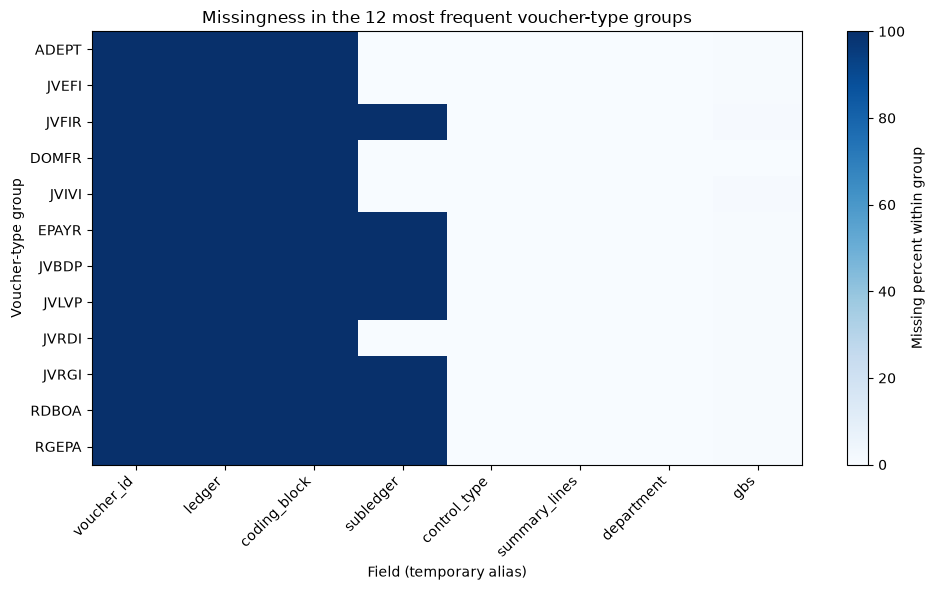

In [11]:
missing_fields = ["voucher_id","ledger","coding_block","subledger","control_type","summary_lines","department","gbs"]
missing_flags = eda[missing_fields].isna()
missing_by = {}
for dimension in ["voucher_type","direction","department","calendar_month","control_type"]:
    grouped_flags = missing_flags.groupby(eda[dimension],dropna=False,observed=True)
    rates = grouped_flags.mean()*100
    rates.insert(0,"records",grouped_flags.size())
    missing_by[dimension] = rates
    print(dimension, "— missing percentages; department/control-type display limited to 12 largest groups")
    display(rates.sort_values("records",ascending=False).head(12) if dimension in ["department","control_type"] else rates)
print("Most common joint missingness patterns (True = missing):")
display(missing_flags.value_counts().head(10).rename("records").to_frame())
print("Voucher-reference presence versus control-type presence:")
display(pd.crosstab(eda.voucher_id.notna().rename("voucher_id_present"), eda.control_type.notna().rename("control_type_present")))
fig, ax = plt.subplots(figsize=(10,6))
heat = missing_by["voucher_type"].nlargest(12,"records")[missing_fields]
image = ax.imshow(heat.to_numpy(),vmin=0,vmax=100,cmap="Blues",aspect="auto")
ax.set_yticks(range(len(heat)),labels=[str(x) for x in heat.index])
ax.set_xticks(range(len(missing_fields)),labels=missing_fields,rotation=45,ha="right")
ax.set(title="Missingness in the 12 most frequent voucher-type groups", xlabel="Field (temporary alias)", ylabel="Voucher-type group")
fig.colorbar(image,ax=ax,label="Missing percent within group")
fig.tight_layout(); plt.show(); plt.close(fig)

**Observation:** the tables show category-dependent coverage, including voucher types with entirely absent subledger, ledger, or coding fields. The joint patterns and voucher-reference/control-type cross-tab distinguish field-presence configurations without assigning record-type labels.

**Documented expectation:** the inventory's dictionary review permits summary-line blanks for voucher transactions and distinguishes control data from voucher entries. **Hypothesis:** some observed missingness reflects these different processes. The exact local row taxonomy and the cause of every blank remain unknown. It would be inappropriate to apply a blanket fill rule or declare missingness random from the overall percentages.

## 12. Extreme Value Investigation

Investigate both ends, retaining original row indices and accounting context. Global p99 and Tukey upper fences (`Q3 + 1.5 × IQR`) are descriptive screening rules, not error labels. Peer fences use direction × voucher type only where there are at least 30 records and a positive IQR; 30 is an exploratory stability guard, not proof of statistical adequacy. No lower-tail rule is applied where a negative fence would be uninformative for nonnegative amounts.

In [12]:
q1, q3 = amount.quantile(.25), amount.quantile(.75)
global_upper_fence = q3 + 1.5*(q3-q1)
peer_keys = ["direction","voucher_type"]
peer_grouped = eda.groupby(peer_keys,dropna=True).amount
peer_n = peer_grouped.transform("size")
peer_q1 = peer_grouped.transform(lambda s:s.quantile(.25))
peer_q3 = peer_grouped.transform(lambda s:s.quantile(.75))
peer_eligible = peer_n.ge(30) & peer_q3.gt(peer_q1)
peer_upper_fence = peer_q3 + 1.5*(peer_q3-peer_q1)
global_candidates = amount > global_upper_fence
peer_candidates = peer_eligible & amount.gt(peer_upper_fence)
extreme_summary = pd.Series({"global_IQR_upper_fence":global_upper_fence,
    "above_global_IQR_count":int(global_candidates.sum()),"global_p99":q99,
    "above_global_p99_count":int((amount>q99).sum()),"peer_eligible_records":int(peer_eligible.sum()),
    "above_peer_IQR_count":int(peer_candidates.sum()),
    "global_IQR_only_among_eligible":int((peer_eligible & global_candidates & ~peer_candidates).sum()),
    "peer_IQR_only_among_eligible":int((peer_candidates & ~global_candidates).sum())})
display(extreme_summary.to_frame("value"))
print("Global/peer comparison only within eligible peer populations:")
display(pd.crosstab(global_candidates[peer_eligible].rename("above_global_fence"),peer_candidates[peer_eligible].rename("above_peer_fence")))
context_fields = ["control","item","effective_date","direction","voucher_type","department","amount","subledger","ledger","coding_block","control_type","summary_lines","voucher_id"]
print("Ten largest records; original zero-based row index retained:")
display(eda.nlargest(10,"amount")[context_fields])
print("Ten smallest records including zeros:")
display(eda.nsmallest(10,"amount")[context_fields])
print("Peer-only candidates: five largest examples:")
display(eda.loc[peer_candidates & ~global_candidates].nlargest(5,"amount")[context_fields])
print("Global-only candidates within eligible peers: five largest examples:")
display(eda.loc[peer_eligible & global_candidates & ~peer_candidates].nlargest(5,"amount")[context_fields])
display(Markdown(f"**Observation:** the global IQR rule selects {global_candidates.sum():,} records ({global_candidates.mean()*100:.2f}%), versus {peer_candidates.sum():,} peer-rule candidates among {peer_eligible.sum():,} eligible records. These denominators differ. There are {amount.eq(0).sum()} zeros; the maximum record belongs to {eda.loc[amount.idxmax(),'voucher_type']} and has summary-line count {eda.loc[amount.idxmax(),'summary_lines']:g}. **Implication:** mixture and aggregation context make a universal cutoff questionable. Neither rule establishes anomalies; peer rules can also fail with skew, small samples, dependence, or mixed record types."))

,value
global_IQR_upper_fence,1.672646e+05
above_global_IQR_count,2.194000e+03
global_p99,7.346044e+09
above_global_p99_count,9.300000e+01
peer_eligible_records,9.107000e+03
above_peer_IQR_count,9.370000e+02
global_IQR_only_among_eligible,1.788000e+03
peer_IQR_only_among_eligible,6.390000e+02


Global/peer comparison only within eligible peer populations:


above_peer_fence,False,True
above_global_fence,,
False,6382,639
True,1788,298


Ten largest records; original zero-based row index retained:


,control,item,effective_date,direction,voucher_type,department,amount,subledger,ledger,coding_block,control_type,summary_lines,voucher_id
5019,202324800003,1,2023-09-01,DR,JVRDI,6.0,3.955579e+10,60000.0,NaN,NaN,CMI,23.0,NaN
3966,202321600001,1,2023-08-03,DR,JVBDP,97.0,3.259303e+10,NaN,NaN,NaN,JMY,74.0,NaN
4947,202324400001,1,2023-08-31,DR,JVBDP,97.0,3.238400e+10,NaN,NaN,NaN,JMY,70.0,NaN
3172,202318800003,1,2023-07-06,DR,JVBDP,97.0,3.121248e+10,NaN,NaN,NaN,JMY,83.0,NaN
1017,202312200008,1,2023-05-01,DR,JVRDI,6.0,2.965005e+10,60000.0,NaN,NaN,CMI,20.0,NaN
5387,202325800003,1,2023-09-14,DR,JVBDP,97.0,2.698105e+10,NaN,NaN,NaN,JMY,74.0,NaN
4430,202323000001,1,2023-08-17,DR,JVBDP,97.0,2.671507e+10,NaN,NaN,NaN,JMY,63.0,NaN
932,202311800001,1,2023-04-27,DR,JVBDP,97.0,2.645298e+10,NaN,NaN,NaN,JMY,68.0,NaN
1839,202314600006,1,2023-05-25,DR,JVBDP,97.0,2.622165e+10,NaN,NaN,NaN,JMY,67.0,NaN
5915,202327200002,1,2023-09-28,DR,JVBDP,97.0,2.505188e+10,NaN,NaN,NaN,JMY,66.0,NaN


...

Peer-only candidates: five largest examples:


,control,item,effective_date,direction,voucher_type,department,amount,subledger,ledger,coding_block,control_type,summary_lines,voucher_id
6559,202329100032,1,2023-10-18,DR,JVEFI,148.0,164014.04,1482100.0,NaN,NaN,CMC,1.0,NaN
307,202310100016,1,2023-04-11,CR,JVEFI,18.0,162237.60,180152.0,NaN,NaN,CMC,1.0,NaN
8047,202333200013,1,2023-11-28,CR,JVEFI,18.0,155383.17,186369.0,NaN,NaN,CMC,7.0,NaN
1307,202313000052,1,2023-05-10,CR,JVEFI,148.0,150021.50,1482100.0,NaN,NaN,CMC,1.0,NaN
2087,202315200049,1,2023-05-31,DR,JVFRD,97.0,149823.23,NaN,NaN,NaN,JMV,1.0,NaN


Global-only candidates within eligible peers: five largest examples:


,control,item,effective_date,direction,voucher_type,department,amount,subledger,ledger,coding_block,control_type,summary_lines,voucher_id
1070,202312400001,1,2023-05-03,DR,JVBDP,97.0,1.220973e+10,NaN,NaN,NaN,JMY,82.0,NaN
8883,202335500003,1,2023-12-20,DR,JVBDP,97.0,1.186733e+10,NaN,NaN,NaN,JMY,74.0,NaN
7148,202330600002,1,2023-11-01,DR,JVBDP,97.0,1.170455e+10,NaN,NaN,NaN,JMY,78.0,NaN
6226,202328300001,1,2023-10-06,DR,JVBDP,97.0,1.163240e+10,NaN,NaN,NaN,JMY,69.0,NaN
199,202309600001,1,2023-04-05,DR,JVBDP,97.0,1.111359e+10,NaN,NaN,NaN,JMY,83.0,NaN


**Observation:** the global IQR rule selects 2,194 records (23.64%), versus 937 peer-rule candidates among 9,107 eligible records. These denominators differ. There are 2 zeros; the maximum record belongs to JVRDI and has summary-line count 23. **Implication:** mixture and aggregation context make a universal cutoff questionable. Neither rule establishes anomalies; peer rules can also fail with skew, small samples, dependence, or mixed record types.

## 13. Potential Anomaly-Detection Groups

Compare group coverage and size before recommending future peers. Only rows with all selected grouping fields populated enter a given group-size calculation; excluded rows remain in the dataset and are counted. Thresholds here describe feasibility, not an approved model design.

In [13]:
peer_options = [["direction"],["voucher_type"],["direction","voucher_type"],
    ["direction","voucher_type","department"],["direction","control_type"],
    ["direction","subledger"],["direction","ledger"],["direction","voucher_type","calendar_month"]]
peer_feasibility_rows = []
for keys in peer_options:
    complete = eda[keys].notna().all(axis=1)
    sizes = eda.loc[complete].groupby(keys,observed=True).size()
    peer_feasibility_rows.append({"grouping":" × ".join(keys),"covered_records":int(complete.sum()),
        "excluded_missing_records":int((~complete).sum()),"groups":len(sizes),"singleton_groups":int(sizes.eq(1).sum()),
        "median_group_size":sizes.median(),"groups_ge30":int(sizes.ge(30).sum()),
        "records_in_groups_ge30":int(sizes[sizes.ge(30)].sum())})
peer_feasibility = pd.DataFrame(peer_feasibility_rows).set_index("grouping")
display(peer_feasibility)

,covered_records,excluded_missing_records,groups,singleton_groups,median_group_size,groups_ge30,records_in_groups_ge30
grouping,,,,,,,
direction,9282,0,2,0,4641.0,2,9282
voucher_type,9256,26,39,0,48.0,20,9112
direction × voucher_type,9256,26,55,8,11.0,25,9107
direction × voucher_type × department,9256,26,188,60,4.0,31,8503
direction × control_type,9104,178,50,8,10.5,23,8974
direction × subledger,7096,2186,532,147,4.0,54,4258
direction × ledger,191,9091,17,7,4.0,2,90
direction × voucher_type × calendar_month,9256,26,353,115,8.0,41,6547


**Candidate hierarchy:** start by examining direction × voucher type, then department where enough comparable records remain. Direction × control type is a useful alternative whose redundancy with voucher type is checked below. Subledger may support selected covered subsets, but does not cover much of the recorded magnitude. Ledger/coding peers have particularly selective coverage. Calendar period is useful context; crossing every group with month can fragment already small groups.

These are future investigation populations, not validated anomaly models. Record-type/summary relationships must be understood before treating observations as independent peers. Missing labels need their own review, not invented categories that pretend to be real accounts. No ML model is built or trained.

## 14. Relationship Analysis

Evaluate associations with plausible meaning: voucher type versus control type, type/department composition, and amount versus documented grouped-detail volume. Do not correlate amounts against numeric identifiers. Spearman correlation below uses two quantitative fields only, excludes missing pairs explicitly, and is descriptive rather than causal.

In [14]:
type_control_counts = eda.loc[eda.voucher_type.notna() & eda.control_type.notna()].groupby(["voucher_type","control_type"]).size()
type_control_cardinality = type_control_counts.groupby(level=0).size().rename("distinct_control_types")
print("Voucher types with more than one observed control type:")
display(type_control_cardinality[type_control_cardinality>1].to_frame())
print("Rows with both codes:", int((eda.voucher_type.notna() & eda.control_type.notna()).sum()))
print("Direction/type/department groups with greatest magnitude:")
display(summarize_amount(["direction","voucher_type","department"]).nlargest(10,"total")[["records","total","median","maximum"]])
line_complete = eda[["amount","summary_lines"]].notna().all(axis=1)
line_spearman = eda.loc[line_complete,["amount","summary_lines"]].corr(method="spearman").loc["amount","summary_lines"]
print("Amount vs summary-line count Spearman; pairs:", int(line_complete.sum()), "rho:", line_spearman)
line_groups = eda.assign(line_count_context=pd.cut(eda.summary_lines,bins=[-np.inf,0,1,10,np.inf],labels=["nonpositive","1","2–10",">10"]))
display(line_groups.groupby("line_count_context",observed=True,dropna=False).amount.agg(["size","median","mean","max"]))
print("Within-type Spearman where n>=30 and summary lines vary:")
line_relations=[]
for label, group in eda.loc[line_complete & eda.voucher_type.notna()].groupby("voucher_type"):
    if len(group)>=30 and group.summary_lines.nunique()>1:
        line_relations.append({"voucher_type":label,"records":len(group),"rho":group[["amount","summary_lines"]].corr(method="spearman").loc["amount","summary_lines"]})
display(pd.DataFrame(line_relations))

Voucher types with more than one observed control type:


,distinct_control_types
voucher_type,


Rows with both codes: 9104
Direction/type/department groups with greatest magnitude:


records         total        median  \
direction voucher_type department                                        
DR        JVBDP        97.0            187  1.297876e+12  4.710401e+09   
          JVRDI        6.0             182  5.066672e+11  1.934094e+05   
          JVRGI        97.0            187  3.699359e+11  1.170940e+09   
          JVLVP        97.0            187  3.591677e+11  1.171680e+09   
          RGEPA        97.0            186  3.156896e+11  8.905017e+08   
CR        GCMO         6.0              70  4.858299e+10  6.246314e+06   
DR        GCMO         6.0              70  4.858299e+10  6.246314e+06   
          RDPCM        97.0             15  4.562250e+10  4.168221e+09   
          JVBRT        6.0             134  2.014802e+10  8.380250e+07   
          JVBRC        6.0               9  1.778028e+10  7.461378e+08   

                                        maximum  
direction voucher_type department                
DR        JVBDP        97.0        3.259303e+10  
          JVRDI        6.0         3.955579e+10  
          JVRGI        97.0        1.271950e+10  
          JVLVP        97.0        9.048852e+09  
          RGEPA        97.0        1.248296e+10  
CR        GCMO         6.0         6.184370e+09  
DR        GCMO         6.0         6.184370e+09  
          RDPCM        97.0        7.282731e+09  
          JVBRT        6.0         1.120232e+09  
          JVBRC        6.0         6.551358e+09

Amount vs summary-line count Spearman; pairs: 9256 rho: 0.3537524284457706


,size,median,mean,max
line_count_context,,,,
1,5766,1.041025e+03,8.940761e+07,1.248296e+10
2–10,2670,2.458565e+03,1.376748e+08,9.048852e+09
>10,820,1.850668e+07,2.652715e+09,3.955579e+10
NaN,26,7.528419e+07,1.133291e+08,4.125333e+08


Within-type Spearman where n>=30 and summary lines vary:


,voucher_type,records,rho
0,ADEPT,3439,0.400198
1,AFDEP,61,0.298872
2,DOMFR,386,0.144243
3,EPAYR,187,-0.021370
4,JVBDP,187,0.291696
5,JVBRT,134,-0.075096
6,JVEFI,2289,0.408741
7,JVEFR,74,0.168410
8,JVIVI,188,0.042445
9,JVLVP,187,0.201849


**Interpretation:** shared type/control classifications may offer redundant grouping information; exceptions should be retained for review rather than forced into a one-to-one mapping. Differences between pooled and within-type amount/line-count associations can reflect category mixture and aggregation. A larger grouped amount may reflect more underlying detail, but line counts do not reveal the distribution of that detail. No division, reconstruction, or deduplication of underlying transactions is justified here.

## 15. Key EDA Findings

This table is generated from the preceding calculations so its numbers remain traceable to executed outputs.

In [15]:
findings = pd.DataFrame([
    ["Strong amount skew", f"Median {amount.median():,.2f}; mean {amount.mean():,.2f}; skewness {amount.skew():.2f}", "Use distribution-aware summaries and contextual comparisons"],
    ["Direction tails differ", f"DR contributes {direction_stats.loc['DR','total']/amount.sum()*100:.2f}% of recorded magnitude", "Direction is useful context, not expense/revenue classification"],
    ["Voucher types separate scales", f"ADEPT median {type_stats.loc['ADEPT','median']:,.2f}; JVBDP median {type_stats.loc['JVBDP','median']:,.2f}", "Investigate voucher-type peers before global thresholds"],
    ["Department concentration", f"Top 2 known departments: {top2_department_amount_share:.2f}% of magnitude; top 5 by count: {top5_department_record_share:.2f}% of rows", "Distinguish activity concentration from value concentration"],
    ["Subledger selection limits", f"Missing labels carry {concentration.loc['subledger','missing_amount_percent']:.2f}% of magnitude", "Account peers represent a selected subset"],
    ["Short and partial temporal coverage", f"{len(daily)} observed dates; January 2024 has {monthly.loc['2024-01','records']:,.0f} rows through January 3", "No full-year seasonality or complete-month January comparison"],
    ["Context-sensitive extreme candidates", f"Global IQR selects {global_candidates.sum():,}; peer IQR selects {peer_candidates.sum():,} within {peer_eligible.sum():,} eligible rows", "Investigate rule disagreement, not automatic removal"],
    ["Missingness varies by category", "Group missingness tables and joint presence patterns in section 11", "Validate structural explanations before cleaning rules"],
    ["Inventory baseline reproduced", "9,282 × 16; zero full duplicates; composite key unique; all dates parse", "No baseline correction is needed"],
],columns=["Finding","Evidence","Potential Relevance"])
display(findings)

,Finding,Evidence,Potential Relevance
0,Strong amount skew,"Median 1,767.72; mean 329,809,199.76; skewness...",Use distribution-aware summaries and contextua...
1,Direction tails differ,DR contributes 98.31% of recorded magnitude,"Direction is useful context, not expense/reven..."
2,Voucher types separate scales,"ADEPT median 620.00; JVBDP median 4,710,400,89...",Investigate voucher-type peers before global t...
3,Department concentration,Top 2 known departments: 99.90% of magnitude; ...,Distinguish activity concentration from value ...
4,Subledger selection limits,Missing labels carry 80.56% of magnitude,Account peers represent a selected subset
5,Short and partial temporal coverage,188 observed dates; January 2024 has 62 rows t...,No full-year seasonality or complete-month Jan...
6,Context-sensitive extreme candidates,"Global IQR selects 2,194; peer IQR selects 937...","Investigate rule disagreement, not automatic r..."
7,Missingness varies by category,Group missingness tables and joint presence pa...,Validate structural explanations before cleani...
8,Inventory baseline reproduced,"9,282 × 16; zero full duplicates; composite ke...",No baseline correction is needed


## 16. Data Quality Issues Identified for Later Investigation

| Status | EDA-supported issue or behavior | Later action to consider; not performed here |
|---|---|---|
| Confirmed limitation | Sparse ledger, voucher-reference, and coding fields; coverage is highly category-dependent | Document field applicability and inspect source rules before any imputation or dropping |
| Confirmed limitation | Subledger missingness covers a disproportionately large share of recorded magnitude | Assess representativeness of account-based analyses |
| Confirmed semantic-type concern | Department, subledger, voucher, and GBS identifiers load as numeric values, including floats | Verify source-preserving identifier representations and leading-zero requirements; no precision defect is inferred from dtype alone |
| Confirmed coverage limit | Effective dates span less than a year; January stops on January 3; dates with no rows exist | Establish extract boundaries and reporting completeness before gap treatment |
| Requires investigation | Zero and very small amounts, very large amounts, and global/peer threshold disagreements | Review accounting context and source evidence; do not remove values merely for extremeness |
| Requires investigation | Summary counts vary and pooled amounts mix accounting processes | Establish record-type relationships and possible overlap before reconciliation or economic totals |
| Requires investigation | Exact fiscal alignment and redistribution/extract provenance | Obtain source clarification; do not infer corrections from effective dates or control-number patterns |
| Expected/documented possibility, not verified row by row | Multiple rows can share an Accounting Control Number; some blanks depend on record type | Preserve legitimate grouping; the observed composite key remains a candidate only |

Baseline checks found no complete duplicates, no invalid effective-date parses, and no missing amount values. These checks do not establish complete business validity. Category codes and numeric extremes are not classified as errors. No cleaning decisions are enacted.

## 17. Implications for Financial Manager AI

| Capability | Inventory assessment retained | Effect of detailed EDA |
|---|---|---|
| Financial Data Analysis | Suitable | Strengthened for descriptive accounting exploration: category-specific amount behavior, concentration, temporal profiles, and coverage limits can be quantified. Recorded totals remain unreconciled magnitudes rather than business revenue/expense/cash facts. |
| Financial Anomaly Detection | Potentially Suitable | Stronger evidence for contextual peer investigation, but greater caution about global cutoffs, missingness, small groups, and unresolved summary/item relationships. No model performance, anomaly labels, or confirmed anomalous transactions are established. |

Other assessments remain unchanged: Accounts Payable **Inadequate**, Budget Variance **Inadequate**, Financial Document RAG **Inadequate**, Cash Flow Forecast **Partial**. No new obligations, budgets, document corpus, or confirmed cash-movement history were introduced by EDA. This notebook does not change the inventory or authorize operational implementation.

## 18. Preliminary EDA Conclusions

**Observations:** amounts are strongly right-skewed; similar DR/CR medians hide different tails. Voucher types and departments differ substantially in scale and frequency. Recorded magnitude is concentrated in a few categories, and missing subledger labels represent a large value share. Effective-date calendar periods show variable counts, totals, medians, and high-value frequencies, with a very short January endpoint. Missingness depends on observed categories. Descriptive global and peer rules select different candidate sets. Section 15 supplies the measured evidence.

**Hypotheses for later investigation:** part of the amount variation and missingness may reflect distinct accounting processes and grouped-detail volume. Period spikes may reflect category mix or reporting schedules. Direction × voucher type, refined by department where sample sizes permit, may yield more meaningful peers than global thresholds. Control type may add or duplicate context. These are hypotheses, not causal conclusions or a trained detection strategy.

**Unresolved questions:** exact fiscal-calendar alignment; precise relationships and overlap among summary and item records; complete Kaggle/local-extract provenance; currency/units and validated accounting semantics; extract completeness; and the availability of reference evidence for evaluating anomaly candidates. The source's mixed-record interpretation remains in force. No fiscal mapping or row-type classification is inferred into existence.

**Next decision, not an action:** review these findings before authorizing a cleaning plan, further source clarification, or model-related work. Do not automatically remove extremes, fill structural blanks, create database keys, or begin Company Financials EDA. The original capability assessments remain appropriate within their documented limits.

### End-to-End Preservation Checks

The final cell compares the original DataFrame against its deep snapshot and a fresh read, verifies every protected raw file and the inventory hash, and reconciles grouped counts/totals. It performs no data repair or export.

In [16]:
pd.testing.assert_frame_equal(raw_df, raw_snapshot)
pd.testing.assert_frame_equal(raw_df, pd.read_csv(raw_path))
assert raw_df.columns.tolist() == expected_columns
for protected_path, original_hash in initial_hashes.items():
    assert hashlib.sha256(Path(protected_path).read_bytes()).hexdigest() == original_hash, protected_path
for table in [direction_stats,type_stats,department_stats,monthly,daily]:
    assert table.records.sum() == len(raw_df)
    assert np.isclose(table.total.sum(),amount.sum(),rtol=1e-12)
assert len(eda) == len(raw_df)
assert baseline["candidate_key_duplicate_occurrences"] == 0
assert not plt.get_fignums()
print("PASS: all raw files and inventory unchanged; original DataFrame values/types preserved; grouped totals reconcile.")
print("Temporary analytical variables remain in this notebook only. No cleaning, ML training, or application implementation performed.")

PASS: all raw files and inventory unchanged; original DataFrame values/types preserved; grouped totals reconcile.
Temporary analytical variables remain in this notebook only. No cleaning, ML training, or application implementation performed.
